In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import itertools

from src.modeling.application_performance_modeling import ApplicationPerformanceModeling

In [2]:
mem_config_list={
    'f1':1536,
    'f2':1792,
    'f3':576,
    'f4':2240,
    'f5':896,
    'f6':1728,
    'f7':128,
    'f8':128,
    'f9':256,
    'f10':320,
    'f11':1920,
    'f12':1984
}

function_duration_dict = {
    'f1': 762.0240333333333,
    'f2': 203.90929, 
    'f3': 522.5909033989267, 
    'f4': 834.7361279646993, 
    'f5': 204.36830394626364, 
    'f6': 508.01780560524736, 
    'f7': 348.3006303418804, 
    'f8': 238.93273666666664, 
    'f9': 163.15264496820052, 
    'f10': 363.3962261380323, 
    'f11': 1009.2928967254406, 
    'f12': 787.6848782535684
}

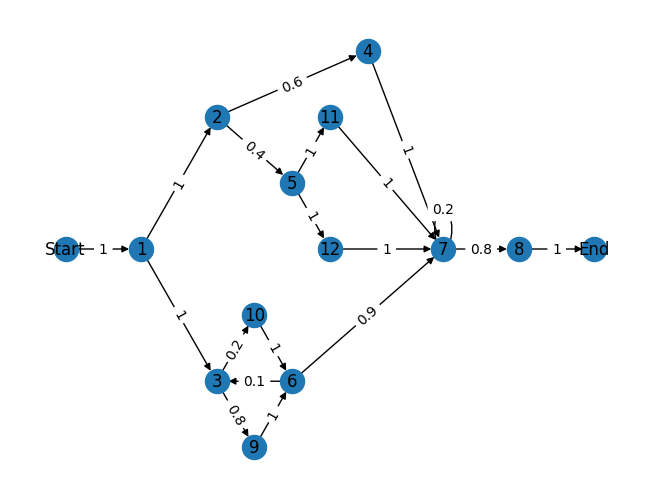

In [3]:
App12_G = nx.DiGraph()
App12_G.add_node('Start', pos=(0, 1))
App12_G.add_node(1, pos=(1, 1), mem = mem_config_list['f1'], rt = function_duration_dict['f1'])
App12_G.add_node(2, pos=(2, 2), mem = mem_config_list['f2'], rt = function_duration_dict['f2'])
App12_G.add_node(3, pos=(2, 0), mem = mem_config_list['f3'], rt = function_duration_dict['f3'])
App12_G.add_node(9, pos=(2.5, -0.5), mem = mem_config_list['f9'], rt = function_duration_dict['f9'])
App12_G.add_node(10, pos=(2.5, 0.5), mem = mem_config_list['f10'], rt = function_duration_dict['f10'])
App12_G.add_node(4, pos=(4, 2.5), mem = mem_config_list['f4'], rt = function_duration_dict['f4'])
App12_G.add_node(5, pos=(3, 1.5), mem = mem_config_list['f5'], rt = function_duration_dict['f5'])
App12_G.add_node(11, pos=(3.5, 2), mem = mem_config_list['f11'], rt = function_duration_dict['f11'])
App12_G.add_node(12, pos=(3.5, 1), mem = mem_config_list['f12'], rt = function_duration_dict['f12'])
App12_G.add_node(6, pos=(3, 0), mem = mem_config_list['f6'], rt = function_duration_dict['f6'])
App12_G.add_node(7, pos=(5, 1), mem = mem_config_list['f7'], rt = function_duration_dict['f7'])
App12_G.add_node(8, pos=(6, 1), mem = mem_config_list['f8'], rt = function_duration_dict['f8'])
App12_G.add_node('End', pos=(7, 1))
App12_G.add_weighted_edges_from([(1, 2, 1),(1, 3, 1),(2, 4, 0.6),(2, 5, 0.4),(4, 7, 1),(5, 11, 1),(5, 12, 1),(11, 7, 1),(12, 7, 1),(3, 9, 0.8),(3, 10, 0.2),(9, 6, 1),(10, 6, 1), (6, 7, 0.9), (6, 3, 0.1), (7, 8, 0.8),(7, 7, 0.2)])
App12_G.add_weighted_edges_from([('Start', 1, 1), (8, 'End', 1)])
pos_App12_G = nx.get_node_attributes(App12_G, 'pos')
nx.draw(App12_G, pos_App12_G, with_labels=True)
labels_App12_G = nx.get_edge_attributes(App12_G, 'weight')
nx.draw_networkx_edge_labels(App12_G, pos_App12_G, edge_labels=labels_App12_G)
pos_higher_offset_App12_G = {}
for k, v in pos_App12_G.items():
    pos_higher_offset_App12_G[k] = (v[0], v[1] + 0.15)
plt.show()

In [4]:
app = ApplicationPerformanceModeling(App12_G, delay_type='SFN')
app.update_ne()
print('Relative number of exectutions reported by modeling:', app.ne)

Relative number of exectutions reported by modeling: {'Start': 0, 1: 1, 2: 1, 3: 1.1111111111111112, 9: 0.888888888888889, 10: 0.22222222222222224, 4: 0.6, 5: 0.4, 11: 0.4, 12: 0.4, 6: 1.1111111111111112, 7: 1.25, 8: 1, 'End': 0}


In [5]:
cost = app.get_avg_cost()
app.get_simple_dag()
rt = app.get_avg_rt()

print('Cost:', cost)
print('Response Time:', rt)

Cost: 1023.2907465277777
Response Time: 3020.1432127375115
